In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

147


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [11]:
i_stepsize = 11
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  11 0.4500000000000001 0.42500000000000016
-------  22 0.5000000000000002 0.4750000000000002
-------  33 0.5000000000000002 0.5250000000000002
-------  44 0.47500000000000014 0.5750000000000003
-------  55 0.4250000000000001 0.6250000000000003
-------  66 0.5250000000000001 0.6500000000000004
-------  77 0.4500000000000001 0.7000000000000004
-------  88 0.5500000000000003 0.7250000000000004
-------  99 0.4250000000000001 0.7750000000000005
-------  110 0.5000000000000002 0.8000000000000005
-------  121 0.5750000000000002 0.8250000000000005
-------  132 0.4500000000000001 0.8750000000000006
-------  143 0.5250000000000001 0.9000000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13311.435770934964
Gradient descend method:  None
RUN  0 , total integrated cost =  13311.435770934964
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21565.177588309605
Gradient descend method:  None
RUN  0 , total integrated cost =  21565.177588309605
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  33 0.5000000000000002 0.525000000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 147
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  11 0.4500000000000001 0.42500000000000016
found solution for  11
-------  22 0.5000000000000002 0.4750000000000002
found solution for  22
-------

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  77 0.4500000000000001 0.7000000000000004
converged for  77
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

file found


In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  65.1621752853778
Gradient descend method:  None
RUN  1 , total integrated cost =  17.906404692314638
RUN  2 , total integrated cost =  17.896638662048048
RUN  3 , total integrated cost =  17.891831961309922
RUN  4 , total integrated cost =  17.890184251001184
RUN  5 , total integrated cost =  17.88906648208003
RUN  6 , total integrated cost =  17.888068443053104
RUN  7 , total integrated cost =  17.88725205837542
RUN  8 , total integrated cost =  17.886572074869942
RUN  9 , total integrated cost =  17.885861917470983
RUN  10 , total integrated cost =  17.88551446184295
RUN  11 , total integrated cost =  17.884184725891174
RUN  12 , total integrated cost =  17.883542792320096
RUN  13 , total integrated cost =  17.883247641632792
RUN  14 , total integrated cost =  17.879647374278626
RUN  15 , total integrated cost =  17.87656606392006
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  566 , total integrated cost =  103.26620876904072
Improved over  566  iterations in  108.43053161166608  seconds by  34.32948277994355  percent.
Problem in initial value trasfer:  Vmean_exc -56.67241510322619 -56.6724121802714
weight =  12889.408130220563
set cost params:  1.0 12889.408130220563 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13309.29459110014
Gradient descend method:  None
RUN  1 , total integrated cost =  13260.939682414755
RUN  2 , total integrated cost =  12830.776016288284
RUN  3 , total integrated cost =  12531.051894338409
RUN  4 , total integrated cost =  12529.254380424696
RUN  5 , total integrated cost =  12529.167833351012
RUN  6 , total integrated cost =  12527.65010375542
RUN  7 , total integrated cost =  12525.810452174179
RUN  8 , total integrated cost =  12525.724761639724
RUN  9 , total integrated cost =  12525.01124382448
RUN  10 , total integrated cost =  12523.95524848766
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  613 , total integrated cost =  12494.406994796049
Improved over  613  iterations in  110.16508864797652  seconds by  6.122695614905112  percent.
Problem in initial value trasfer:  Vmean_exc -56.67228138254822 -56.67228299996781
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  96.01989676896412
Gradient descend method:  None
RUN  1 , total integrated cost =  18.94237224128601
RUN  2 , total integrated cost =  18.936938132179588
RUN  3 , total integrated cost =  18.932693059754303
RUN  4 , total integrated cost =  18.930348120363977
RUN  5 , total integrated cost =  18.928682767319867
RUN  6 , total integrated cost =  18.926583463441172
RUN  7 , total integrated cost =  18.92508836575272
RUN  8 , total integrated cost =  18.923636022065196
RUN  9 , total integrated cost =  18.922918500738835
RUN  10 , total integrated cost =  18.92171021222774
RUN 

...

RUN  1000 , total integrated cost =  6715.0629709908635
RUN  1000 , total integrated cost =  6715.0629709908635
Improved over  1000  iterations in  170.66483730636537  seconds by  33.05437145417267  percent.
Problem in initial value trasfer:  Vmean_exc -56.65234983548805 -56.65234977056117
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  116.00172438225133
Gradient descend method:  None
RUN  1 , total integrated cost =  113.89520260412624
RUN  2 , total integrated cost =  113.89329305254842
RUN  3 , total integrated cost =  113.89304402432853
RUN  4 , total integrated cost =  113.89281206777547
RUN  5 , total integrated cost =  113.89256051832645
RUN  6 , total integrated cost =  113.89231255563759
RUN  7 , total integrated cost =  113.89206000331959
RUN  8 , total integrated cost =  113.89179120833082
RUN  9 , total integrated cost =  113.89153618030869
RUN  10 , total integrated c

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  440 , total integrated cost =  5305.846516515333
Improved over  440  iterations in  112.17284128256142  seconds by  17.1770484558822  percent.
Problem in initial value trasfer:  Vmean_exc -56.70049271122046 -56.70049625668662
weight =  440.60283878777716
set cost params:  1.0 440.60283878777716 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23375.027450903322
Gradient descend method:  None
RUN  1 , total integrated cost =  5426.822137222302
RUN  2 , total integrated cost =  4778.635051707014
RUN  3 , total integrated cost =  4767.913302974742
RUN  4 , total integrated cost =  4767.697495830333
RUN  5 , total integrated cost =  4767.488454694749
RUN  6 , total integrated cost =  4767.320301620061
RUN  7 , total integrated cost =  4767.162827622511
RUN  8 , total integrated cost =  4767.021704360264
RUN  9 , total integrated cost =  4766.889199919645
RUN  10 , total integrated cost =  4766.764382155506
RUN  11 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  101 , total integrated cost =  4699.543914029219
Improved over  101  iterations in  18.516350680962205  seconds by  79.8950229089566  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053135232392 -56.70053223421956


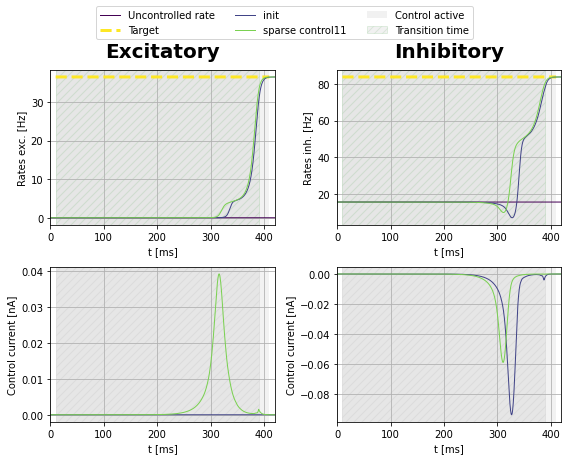

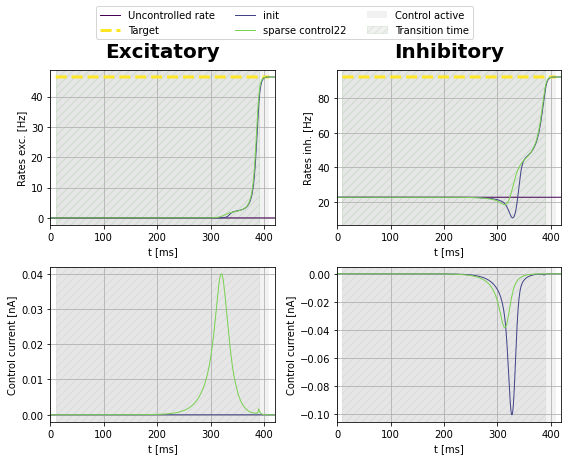

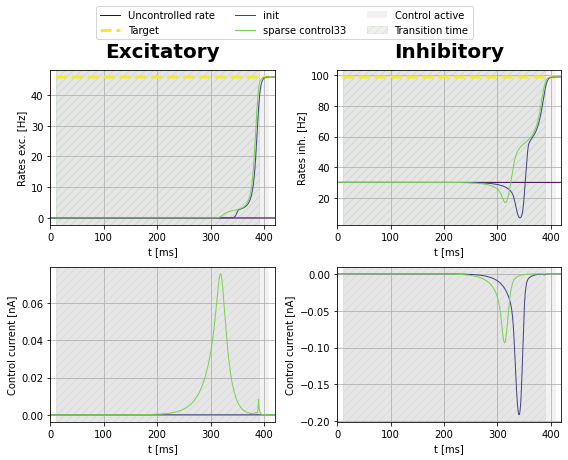

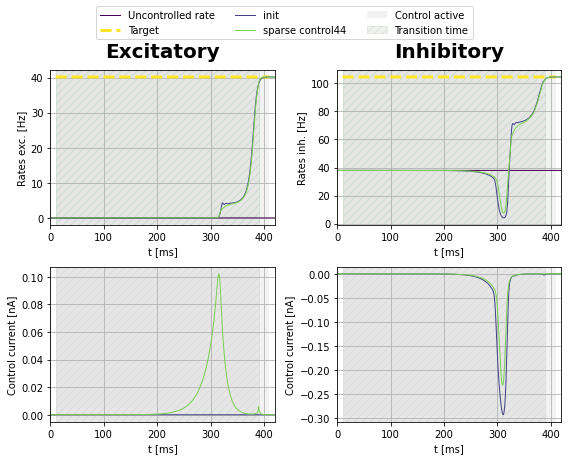

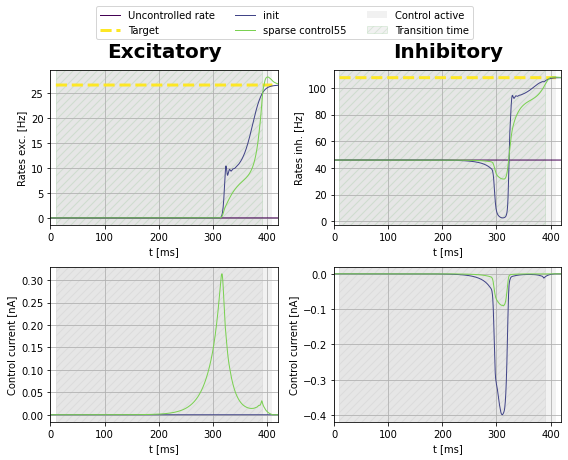

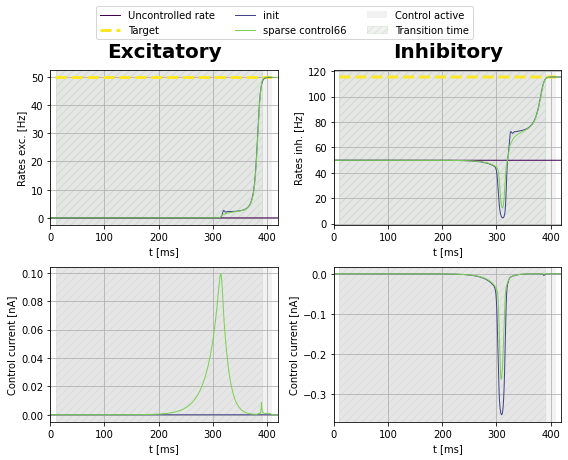

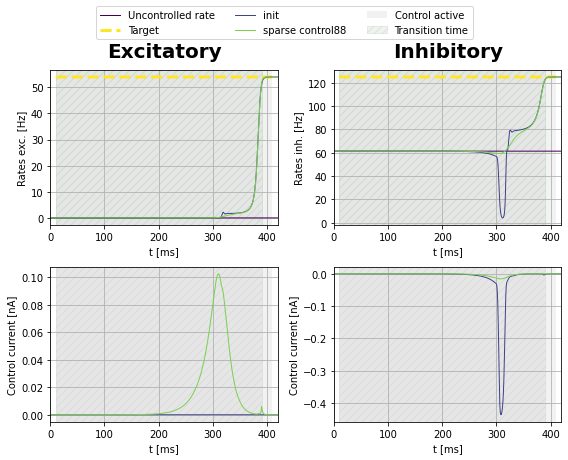

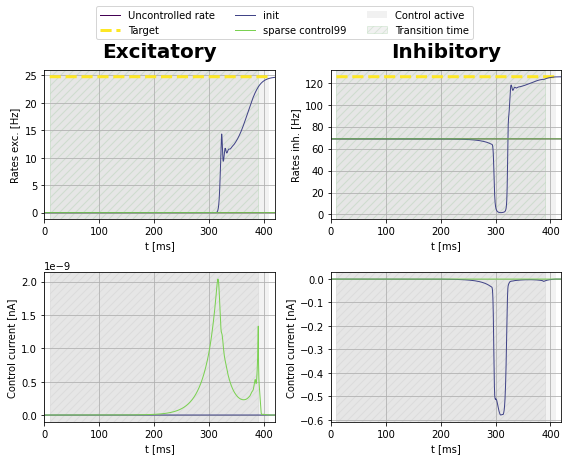

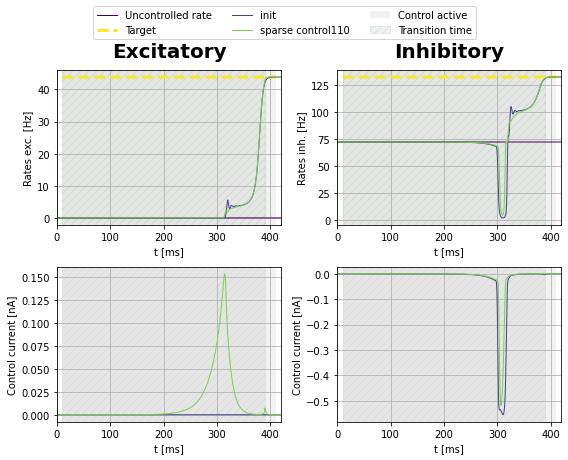

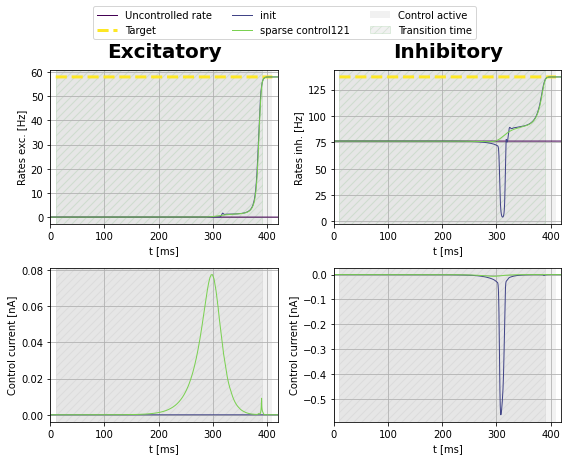

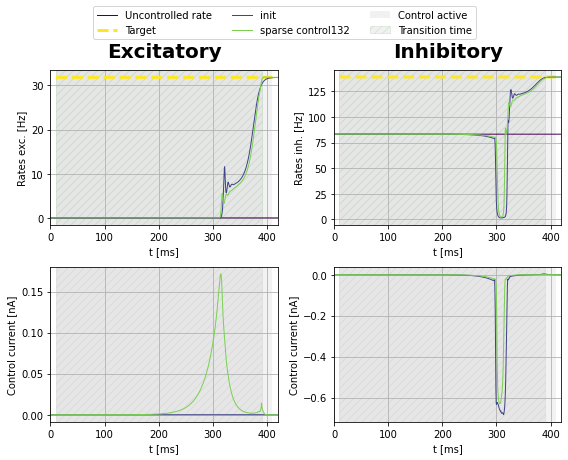

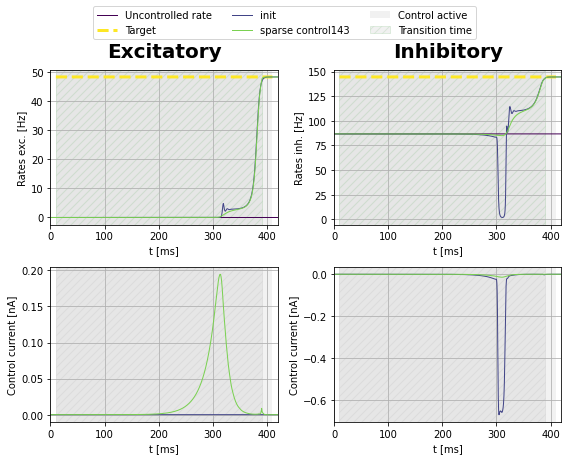

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
weight =  13731.266647169408
set cost params:  1.0 13731.266647169408 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13309.58600059724
Gradient descend method:  None
RUN  1 , total integrated cost =  13309.561539806096
RUN  2 , total integrated cost =  13309.561425712896
RUN  3 , total integrated cost =  13309.561425180746
RUN  4 , total integrated cost =  13309.561425175776
RUN  5 , total integrated cost =  13309.56142517574
RUN  6 , total integrated cost =  13309.561425175727
RUN  7 , total integrated cost =  13309.561425175722


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  13309.561425175722
Control only changes marginally.
RUN  8 , total integrated cost =  13309.561425175722
Improved over  8  iterations in  3.1027468983083963  seconds by  0.00018464452251976127  percent.
Problem in initial value trasfer:  Vmean_exc -56.672278143012235 -56.67227983992411
-------  22 0.5000000000000002 0.4750000000000002
no convergence
weight =  25037.396452812416
set cost params:  1.0 25037.396452812416 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21556.448692515543
Gradient descend method:  None
RUN  1 , total integrated cost =  21555.74940064728
RUN  2 , total integrated cost =  21555.747149555093
RUN  3 , total integrated cost =  21555.74704828469
RUN  4 , total integrated cost =  21555.74703600322
RUN  5 , total integrated cost =  21555.747030349794
RUN  6 , total integrated cost =  21555.747024489272
RUN  7 , total integrated cost =  21555.747021288527
RUN  8 , total integrated cost =  21555.7470181414

ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  21555.747018057158
Control only changes marginally.
RUN  14 , total integrated cost =  21555.747018057158
Improved over  14  iterations in  5.747469764202833  seconds by  0.003255055915715843  percent.
Problem in initial value trasfer:  Vmean_exc -56.69837872238844 -56.69837903268143
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  6953.09354828853
set cost params:  1.0 6953.09354828853 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21065.875308705956
Gradient descend method:  None
RUN  1 , total integrated cost =  21065.404060303168
RUN  2 , total integrated cost =  21065.145605431386
RUN  3 , total integrated cost =  21064.901138302
RUN  4 , total integrated cost =  21064.531980453416
RUN  5 , total integrated cost =  21064.146655706954
RUN  6 , total integrated cost =  21063.8035171116
RUN  7 , total integrated cost =  21063.375937728564
RUN  8 , total integrated cost =  21063.00844850268
RUN  

...

RUN  3 , total integrated cost =  21066.131127604975
Control only changes marginally.
RUN  3 , total integrated cost =  21066.131127604975
Improved over  3  iterations in  1.2944788411259651  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.69735751756677 -56.69735764063431
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
no convergence
weight =  350.9492306611349
set cost params:  1.0 350.9492306611349 0.0
interpolate adjoint :  True True True
RUN  0 , total integrate

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10088.826336075685
Control only changes marginally.
RUN  1 , total integrated cost =  10088.826336075685
Improved over  1  iterations in  0.43838081508874893  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.65241677391571 -56.652414502490544
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 8
[[True, True], [True, True], [True, True], [False, False], [True, True], [True, True], [True, False], [True, True], [True, False], [True, True], [True, True], [True, True], [False, False], [True, True]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
no convergence
weight =  7019.174791951409
set cost params:  1.0 7019.174791951409 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  21066.13112760497
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  21066.13112760497
Control only changes marginally.
RUN  1 , total integrated cost =  21066.13112760497
Improved over  1  iterations in  0.44197335839271545  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69735751756677 -56.69735764063431
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
converged for  88
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
converged for  110
-------  121 0.5750000000000002 0.8250000000000005
converged for  121
-------  132 0.4500000000000001 0.8750000000000006
converged for  132
-------  143 0.5250000000000001 0.9000000000000006
converged for  143
--------------- 9
[[True, True], [True, True], [True, True], [False, False], [T

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

file found


In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[ 11  22  33  44  55  66  88  99 110 121 132 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  11 0.4500000000000001 0.42500000000000016
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15.25759234886214
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9956324537030448
RUN  2 , total integrated cost =  0.9947979306283347
RUN  3 , total integrated cost =  0.994538669829698
RUN  4 , total integrated cost =  0.9942785511806822
RUN  5 , total integrated cost =  0.9942544300972964
RUN  6 , total integrated cost =  0.9942110072709921
RUN  7 , total integrated cost =  0.9941854073155266
RUN  8 , total integrated cost =  0.994075136737972
RUN  9 , total integrated cost =  0.9939737593976958
RUN  10 , total integrated cost =  0.9831596729703473
RUN  11 , total integrated cost =  0.9823169302452818
RUN  12 , total integrated cost =  0.9823155782942955
RUN  13 , total integrated cost =  0.9822065041686323
RUN  14 , total integrated cost =  0.982105743235068
RUN  15 , total integrated cost =  0.9821049660089803


ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  44 , total integrated cost =  0.9808108454074247
Improved over  44  iterations in  2.989567507058382  seconds by  93.57165388233373  percent.
Problem in initial value trasfer:  Vmean_exc -56.67236067906048 -56.67236038784133
-------  22 0.5000000000000002 0.4750000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  45.60743057999414
Gradient descend method:  None
RUN  1 , total integrated cost =  0.8860985723759066
RUN  2 , total integrated cost =  0.8858059754163939
RUN  3 , total integrated cost =  0.8857516887733315
RUN  4 , total integrated cost =  0.885684595800624
RUN  5 , total integrated cost =  0.8856557418138816
RUN  6 , total integrated cost =  0.885608297324731
RUN  7 , total integrated cost =  0.8855771659167975
RUN  8 , total integrated cost =  0.8854762815229885
RUN  9 , total integrated cost =  0.885395730930475
RUN  10 , total integrated cost =  0.8846508053328146
RUN  11 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  72 , total integrated cost =  0.8784046451703929
Improved over  72  iterations in  5.001507841050625  seconds by  98.07398786995971  percent.
Problem in initial value trasfer:  Vmean_exc -56.69838823151646 -56.698388211005366
-------  33 0.5000000000000002 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17.079165551552276
Gradient descend method:  None
RUN  1 , total integrated cost =  3.0416424621893374
RUN  2 , total integrated cost =  3.0414147608734803
RUN  3 , total integrated cost =  3.0413891470740144
RUN  4 , total integrated cost =  3.0413478679686703
RUN  5 , total integrated cost =  3.0413424780873655
RUN  6 , total integrated cost =  3.041316647226005
RUN  7 , total integrated cost =  3.041300887566502
RUN  8 , total integrated cost =  3.041244286467713
RUN  9 , total integrated cost =  3.0411754384486502
RUN  10 , total integrated cost =  3.041170110284775
RUN  11

...

Control only changes marginally.
RUN  254 , total integrated cost =  2.491448595216414
Improved over  254  iterations in  16.215544359758496  seconds by  78.80945757708903  percent.
Problem in initial value trasfer:  Vmean_exc -56.70343363136813 -56.703433712628176
-------  132 0.4500000000000001 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  29.421281764692875
Gradient descend method:  None
RUN  1 , total integrated cost =  28.915051915325655
RUN  2 , total integrated cost =  28.91498489015224
RUN  3 , total integrated cost =  28.91498212822571
RUN  4 , total integrated cost =  28.91498125054348
RUN  5 , total integrated cost =  28.91497749481934
RUN  6 , total integrated cost =  28.91491507965259
RUN  7 , total integrated cost =  28.91489549988717
RUN  8 , total integrated cost =  28.914894387979952
RUN  9 , total integrated cost =  28.914893200008592
RUN  10 , total integrated cost =  28.91484520048489
RUN  11

ERROR:root:Problem in initial value trasfer


RUN  60 , total integrated cost =  28.862372110577038
Control only changes marginally.
RUN  61 , total integrated cost =  28.862372110577038
Improved over  61  iterations in  4.014558242633939  seconds by  1.8996781261466253  percent.
Problem in initial value trasfer:  Vmean_exc -56.652377847317695 -56.652376984985246
-------  143 0.5250000000000001 0.9000000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.510360428562517
Gradient descend method:  None
RUN  1 , total integrated cost =  10.699723267228183
RUN  2 , total integrated cost =  10.698049241742092
RUN  3 , total integrated cost =  10.698047228374264
RUN  4 , total integrated cost =  10.697796967757615
RUN  5 , total integrated cost =  10.697539303445662
RUN  6 , total integrated cost =  10.69750158022639
RUN  7 , total integrated cost =  10.697473283988293
RUN  8 , total integrated cost =  10.697467837754626
RUN  9 , total integrated cost =  10.697458162639602
R

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  347 , total integrated cost =  10.693325701305856
Improved over  347  iterations in  22.162763779982924  seconds by  20.850922091620248  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053548804324 -56.70053613360475


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

ERROR:root:Problem in initial value trasfer


--------------- 0
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9808108454074247
Gradient descend method:  None
RUN  1 , total integrated cost =  0.9808108454074247
Control only changes marginally.
RUN  1 , total integrated cost =  0.9808108454074247
Improved over  1  iterations in  0.15147959627211094  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67236067906048 -56.67236038784133
-------  22 0.5000000000000002 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.8784046451703929
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.8784046451703929
Control only changes marginally.
RUN  1 , total integrated cost =  0.8784046451703929
Improved over  1  iterations in  0.15104788541793823  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69838823151646 -56.698388211005366
-------  33 0.5000000000000002 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  3.0229610477710986
Gradient descend method:  None
RUN  1 , total integrated cost =  3.0229610477710986
Control only changes marginally.
RUN  1 , total integrated cost =  3.0229610477710986
Improved over  1  iterations in  0.15338736027479172  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.697362038005686 -56.697362017735905
-------  44 0.47500000000000014 0.5750000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  9.017754

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  4.082545739372222
Control only changes marginally.
RUN  1 , total integrated cost =  4.082545739372222
Improved over  1  iterations in  0.15276277251541615  seconds by  0.0  percent.
-------  99 0.4250000000000001 0.7750000000000005
converged for  99
-------  110 0.5000000000000002 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14.05886235140866
Gradient descend method:  None
RUN  1 , total integrated cost =  14.05886235140866
Control only changes marginally.
RUN  1 , total integrated cost =  14.05886235140866
Improved over  1  iterations in  0.1517206560820341  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.693098554956116 -56.693099360536785
-------  121 0.5750000000000002 0.8250000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.491448595216414
Gradient de

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.491448595216414
Control only changes marginally.
RUN  1 , total integrated cost =  2.491448595216414
Improved over  1  iterations in  0.15021011978387833  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70343363136813 -56.703433712628176
-------  132 0.4500000000000001 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28.862372110577038
Gradient descend method:  None
RUN  1 , total integrated cost =  28.862372110577038
Control only changes marginally.
RUN  1 , total integrated cost =  28.862372110577038
Improved over  1  iterations in  0.1555471085011959  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.652377847317695 -56.652376984985246
-------  143 0.5250000000000001 0.9000000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.6933257

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  10.693325701305856
Control only changes marginally.
RUN  1 , total integrated cost =  10.693325701305856
Improved over  1  iterations in  0.151697164401412  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70053548804324 -56.70053613360475
--------------- 11
[[True, True], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, True], [False, False], [True, False], [False, False], [False, False], [False, False], [False, False]]
-------  11 0.4500000000000001 0.42500000000000016
converged for  11
-------  22 0.5000000000000002 0.4750000000000002
converged for  22
-------  33 0.5000000000000002 0.5250000000000002
converged for  33
-------  44 0.47500000000000014 0.5750000000000003
converged for  44
-------  55 0.4250000000000001 0.6250000000000003
converged for  55
-------  66 0.5250000000000001 0.6500000000000004
converged for  66
-------  88 0.5500000000000003 0.7250000000000004
c

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
